# Churn Predictor
This notebook aims to study the data gathered from a Bank to predict customer churn.

The game plan is the following:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
    + Data Unsampling using SMOTE
    + Principal Component Analysis Of One Hot Encoded Data
3. Model Selection and Evaluation
    + Cross Validation
    + Model Evaluation
    + Model Evaluation On Original Data (Before Upsampling)
5. Improvements
    + Threshold Tuning
    + Reduced SMOTE Ratio

In [2]:
import pandas as pd

data = pd.read_csv("BankChurners.csv")

# Target
target = "Attrition_Flag"

# Numerical features (EDA-driven)
numerical_features = [
    # Transaction behavior
    "Total_Trans_Ct",
    "Total_Trans_Amt",
    "Avg_Utilization_Ratio",
    "Total_Ct_Chng_Q4_Q1",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Revolving_Bal",

    # Engagement & relationship
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Total_Relationship_Count",

    # Demographic / tenure
    "Customer_Age",
    "Months_on_book",
    "Dependent_count",
]

# Categorical features (EDA-selected)
categorical_features = [ # Marital_Status --> weak signaL
    "Gender",
    "Education_Level",
    "Income_Category",
    "Card_Category",
]


# Build modeling dataframe
df = data[numerical_features + categorical_features + [target]].copy()



In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # ensures that the class ratio remains the same in 
)


In [4]:
# 2. Encoding (fit on train, transform train and test)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns

# OneHot Encoder
encoder = ColumnTransformer( # EXPLICAR
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]

)

# Fit on training data only
X_train_enc = encoder.fit_transform(X_train)

# Transform test data using learned categories
X_test_enc = encoder.transform(X_test)


In [5]:
# 3. SMOTE (only on training data)
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the encoded training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)


In [6]:
# 4. Scaling (fit on training data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler on SMOTEd training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Apply the same transformation to test data
X_test_scaled = scaler.fit_transform(X_test_enc)

print("Scaled Train data shape: ", X_train_scaled.shape)
print("Scaled Test data shape: ", X_test_scaled.shape)

Scaled Train data shape:  (13598, 31)
Scaled Test data shape:  (2026, 31)


In [7]:
# 5. PCA (fit on training data, optional)
from sklearn.decomposition import PCA 

# Initialize PCA to retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)


# Fit PCA on scaled training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Fit PCA on scaled test data
X_test_pca = pca.transform(X_test_scaled)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # StratifiedKFold defines how the training set is divided during cross-validation.

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators = 1000,
        learning_rate = 0.01,
        max_depth = 4,
        subsample = 0.8,
        colsample_bytree=0.8,
        reg_lambda =1.0,
        random_state = 42,
        eval_metric = "logloss",
        n_jobs = 1
    )
}

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision"
}

cv_results = {}

y_train_bin = (y_train_smote == "Attrited Customer").astype(int) # in smote target is STRING so we transformed it to int

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train_pca, # PCA-reduced training data
        y_train_bin, # Balanced target
        cv = cv,
        scoring=scoring,
        n_jobs=1
    )
    cv_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring}

print(pd.DataFrame((cv_results)))

           Logistic Regression  Random Forest  Gradient Boost   XGBoost
roc_auc               0.892179       0.982779        0.950235  0.964982
f1                    0.818156       0.934509        0.880244  0.901318
recall                0.819089       0.932784        0.872626  0.895278
precision             0.817392       0.936264        0.888036  0.907461


In [9]:
# 3.2  Model Evaluation

# Train final model on full SMOTEd training data
final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train_pca, y_train_smote) # Why PCA on set

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predictions
y_test_pred = final_model.predict(X_test_pca)
y_test_proba = final_model.predict_proba(X_test_pca)[:, 1] #???
    # predict_proba() gives you the estimated probability of each class
    # y_test_pred_xgb[:, 1] = probabilidad de la clase positiva (churn / Attrited)


# Metrics
print("Classification Report (Test Set): \n", classification_report(y_test, y_test_pred), "\n")
print("ROC-AUC (Test Set): " , roc_auc_score(y_test, y_test_proba))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_test_pred))


Classification Report (Test Set): 
                    precision    recall  f1-score   support

Attrited Customer       0.44      0.84      0.57       325
Existing Customer       0.96      0.79      0.87      1701

         accuracy                           0.80      2026
        macro avg       0.70      0.82      0.72      2026
     weighted avg       0.88      0.80      0.82      2026
 

ROC-AUC (Test Set):  0.8951612173834396
Confusion Matrix: 
 [[ 274   51]
 [ 355 1346]]


In [ ]:
#  3.3  Model Evaluation On Original Data (Before Upsampling)
# How does the model behave under real-world class imbalance?

# Transform original (non-SMOTEd) training data
X_train_orig_scaled = scaler.transform(X_train_enc)
X_train_orig_pca = pca.transform(X_train_orig_scaled)

#
# True labels (binary)
c = (y_train == "Attrited Customer").astype(int)

# Predictions from RF (strings -> binary)
y_train_orig_pred = final_model.predict(X_train_orig_pca)
y_train_orig_pred_bin = (y_train_orig_pred == "Attrited Customer").astype(int)

# Probabilities (take probability of the positive class)
pos_index = list(final_model.classes_).index("Attrited Customer")
y_train_orig_proba = final_model.predict_proba(X_train_orig_pca)[:, pos_index]

print("Random Forest — Evaluation on Original (Imbalanced) Training Data")
print(classification_report(y_train_orig_bin, y_train_orig_pred_bin))
print("ROC-AUC:", roc_auc_score(y_train_orig_bin, y_train_orig_proba))
print("Confusion Matrix:\n", confusion_matrix(y_train_orig_bin, y_train_orig_pred_bin))

Random Forest — Evaluation on Original (Imbalanced) Training Data
              precision    recall  f1-score   support

           0       0.99      0.83      0.91      6799
           1       0.53      0.97      0.68      1302

    accuracy                           0.85      8101
   macro avg       0.76      0.90      0.79      8101
weighted avg       0.92      0.85      0.87      8101

ROC-AUC: 0.9726957904038025
Confusion Matrix:
 [[5661 1138]
 [  41 1261]]


## Threshold tuning 
Rather than relying on the default probability threshold of 0.5, adjusting the classification threshold allows explicit control over the precision–recall trade-off. Increasing the threshold makes the model more selective when flagging customers as potential churners, thereby reducing false positives while preserving most of the model’s ability to identify true churners. This approach is particularly well aligned with business contexts,where the operational cost of unnecessary customer interventions must be balanced against the risk of missing at-risk customers.

In [16]:
# 1. Probabilities for the positive (Attrited Customer) class
pos_class_index = list(final_model.classes_).index("Attrited Customer") # "0" as negative class
y_proba = final_model.predict_proba(X_test_pca)[:, pos_class_index]
print(pos_class_index, y_proba)


0 [0.06 0.86 0.27 ... 0.71 0.07 0.35]


In [ ]:
# Eval metrics at different thresholds
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.3, 0.9, 0.05)

y_test_bin = (y_test == "Attrited Customer").astype(int)

results=[]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int) # "0" as negative if < threshold
    precision = precision_score(y_test_bin, y_pred_threshold)
    recall = recall_score(y_test_bin, y_pred_threshold)
    f1 = f1_score(y_test_bin, y_pred_threshold)
    # print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

threshold_df = pd.DataFrame(results)
print(threshold_df)

    Threshold  Precision    Recall  F1-Score
0        0.30   0.303091  0.935385  0.457831
1        0.35   0.331479  0.916923  0.486928
2        0.40   0.370513  0.889231  0.523077
3        0.45   0.399154  0.870769  0.547389
4        0.50   0.435612  0.843077  0.574423
5        0.55   0.468007  0.787692  0.587156
6        0.60   0.504167  0.744615  0.601242
7        0.65   0.552567  0.695385  0.615804
8        0.70   0.600000  0.646154  0.622222
9        0.75   0.654110  0.587692  0.619125
10       0.80   0.710744  0.529231  0.606702
11       0.85   0.769231  0.461538  0.576923
12       0.90   0.827338  0.353846  0.495690
Optimal Threshold:
 Threshold    0.500000
Precision    0.435612
Recall       0.843077
F1-Score     0.574423
Name: 4, dtype: float64


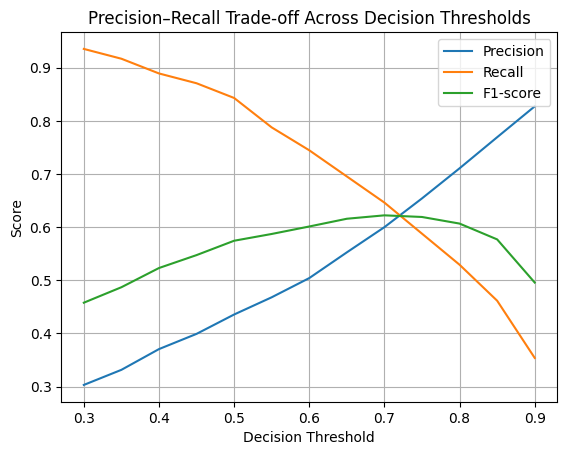

In [26]:
import matplotlib.pyplot as plt
# Plot
plt.figure()
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Decision Thresholds")
plt.legend()
plt.grid(True)
plt.show()

The threshold analysis reveals a clear trade-off between precision and recall. As the decision threshold increases, the model becomes more selective, leading to higher precision at the expense of recall.

From a business perspective, both types of classification errors carry meaningful costs. A model with very high recall but low precision correctly identifies most churners but generates a large number of false positives. This results in unnecessary retention actions, increased operational costs (e.g. discounts, incentives, call centre activity), and potential customer fatigue from excessive or irrelevant contact. While such a model minimises missed churners, it often lacks cost efficiency at scale.

Conversely, a model with very high precision but low recall focuses retention efforts on a small, highly reliable group of customers, reducing wasted interventions and improving operational efficiency. However, this comes at the cost of missing a substantial proportion of actual churners, leading to lost revenue, higher customer acquisition costs, and reduced long-term customer lifetime value.

Given these trade-offs, this project prioritises high precision (not below 0.70) while maintaining a reasonable level of recall to preserve the preventative value of the model. Higher decision thresholds (approximately 0.80–0.85) therefore offer a more business-aligned balance, enabling targeted, cost-effective retention strategies without excessively sacrificing churn detection.

Threshold: 0.80   0.710744 (Precision)  0.529231 (Recall) 0.606702 (F1-Score)

In [31]:
DECISION_THRESHOLD = 0.80

# Probabilities for the positive class
pos_idx = list(final_model.classes_).index("Attrited Customer")
y_test_proba = final_model.predict_proba(X_test_pca)[:, pos_idx]

# Apply selected threshold
y_test_pred_thr = (y_test_proba >= DECISION_THRESHOLD).astype(int)
y_test_pred_no_thr = (y_test_proba >= 0.5).astype(int) # default threshold
y_test_bin = (y_test == "Attrited Customer").astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("===== Results at Different Thresholds =====")
print(f"Results at Decision Threshold = {DECISION_THRESHOLD}")
print(classification_report(y_test_bin, y_test_pred_thr))
print("Confusion Matrix:\n", confusion_matrix(y_test_bin, y_test_pred_thr))
print("===============================================")
print("Results at Default Threshold = 0.5")
print(classification_report(y_test_bin, y_test_pred_no_thr))
print("Confusion Matrix:\n", confusion_matrix(y_test_bin, y_test_pred_no_thr))



===== Results at Different Thresholds =====
Results at Decision Threshold = 0.8
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1701
           1       0.71      0.53      0.61       325

    accuracy                           0.89      2026
   macro avg       0.81      0.74      0.77      2026
weighted avg       0.88      0.89      0.88      2026

Confusion Matrix:
 [[1631   70]
 [ 153  172]]
Results at Default Threshold = 0.5
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      1701
           1       0.44      0.84      0.57       325

    accuracy                           0.80      2026
   macro avg       0.70      0.82      0.72      2026
weighted avg       0.88      0.80      0.82      2026

Confusion Matrix:
 [[1346  355]
 [  51  274]]


### Comparison of Results With and Without Threshold Tuning

The comparison between the default decision threshold (0.5) and the tuned
threshold (0.8) highlights the practical impact of threshold selection on model
behaviour and business relevance.

At the **default threshold (0.5)**, the model strongly prioritises recall for
attrited customers, correctly identifying most churners (recall = 0.84).
However, this comes at the cost of low precision (0.44), resulting in a large
number of false positives and an inflated retention campaign size.

After applying **threshold tuning (0.8)**, the model becomes significantly more
selective. Precision for the churn class increases substantially (from 0.44 to
0.71), while recall decreases to 0.53. This reduction in recall is accompanied
by a sharp drop in false positives, leading to a more focused and
cost-effective retention strategy. Overall accuracy also improves (from 0.80 to
0.89), reflecting better alignment between predictions and true customer
behaviour.

These results demonstrate that threshold tuning enables explicit control over
the precision–recall trade-off. In this project, the tuned threshold provides a
more business-aligned balance, prioritising precision while maintaining a
meaningful level of churn detection.


### Reduce SMOTE ratio
The SMOTE sampling ratio can be reduced to limit over-sensitisation to the minority class. Fully balancing the training data can lead the model to overestimate churn likelihood, increasing the false positive rate. By applying SMOTE with a less aggressive sampling strategy (e.g. minority class representing 60–70% of the majority class), the model is still exposed to sufficient churn examples while retaining a closer resemblance to real-world class distributions. This adjustment often leads to improved precision with only a moderate reduction in recall, resulting in a more operationally efficient and realistic churn prediction model.


In [38]:

# Reduce SMOTE ratio experiment
smote_ratios = [0.6, 0.7, 0.8, 1.0]  # 1.0 = fully balanced (your current baseline)

results = []

# Binary targets (needed for metrics + roc_auc)
y_test_bin = (y_test == "Attrited Customer").astype(int)

for ratio in smote_ratios:
    # 1) SMOTE on training only
    smote = SMOTE(sampling_strategy=ratio, random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

    y_train_sm_bin = (y_train_sm == "Attrited Customer").astype(int)

    # 2) Scale (fit on SMOTEd train, transform both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sm)
    X_test_scaled = scaler.transform(X_test_enc)

    # 3) PCA (fit on scaled train only, transform both)
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # 4) Train model (Random Forest)
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train_pca, y_train_sm)  # keep string labels so predict() matches your workflow

    # 5) Predict probabilities on test, apply threshold
    pos_idx = list(model.classes_).index("Attrited Customer")
    y_test_proba = model.predict_proba(X_test_pca)[:, pos_idx]
    y_test_pred_thr = (y_test_proba >= DECISION_THRESHOLD).astype(int)

    # 6) Metrics (for churn class = 1)
    precision = precision_score(y_test_bin, y_test_pred_thr)
    recall = recall_score(y_test_bin, y_test_pred_thr)
    f1 = f1_score(y_test_bin, y_test_pred_thr)
    roc_auc = roc_auc_score(y_test_bin, y_test_proba)

    cm = confusion_matrix(y_test_bin, y_test_pred_thr)

    results.append({
        "smote_ratio": ratio,
        "pca_components": X_train_pca.shape[1],
        "precision_churn": precision,
        "recall_churn": recall,
        "f1_churn": f1,
        "roc_auc": roc_auc,
        "false_positives": int(cm[0, 1]),
        "false_negatives": int(cm[1, 0]),
        "threshold": DECISION_THRESHOLD
    })

results_df = pd.DataFrame(results).sort_values(["precision_churn", "recall_churn"], ascending=False)
results_df


,smote_ratio,pca_components,precision_churn,recall_churn,f1_churn,roc_auc,false_positives,false_negatives,threshold
1,0.7,22,0.930000,0.286154,0.437647,0.916123,7,232,0.8
0,0.6,22,0.924731,0.264615,0.411483,0.914417,7,239,0.8
2,0.8,22,0.923077,0.295385,0.447552,0.912985,8,229,0.8
3,1.0,22,0.917431,0.307692,0.460829,0.912763,9,225,0.8
